# CellChat

In [1]:
library_load <- suppressMessages(
    
    suppressWarnings(
        
        list(

            # CellTalk
            library(CellChat), 

            # Seurat 
            library(Seurat), 

            # Data 
            library(tidyverse), 

            # Plotting 
            library(ComplexHeatmap), 
            library(circlize), 
            library(viridis), 
            library(ggplotify), 
            library(ggrepel), 
            library(cowplot), 

            # Pyhton compatibility
            library(reticulate)

        )
    
    )

)

In [2]:
# Configure reticulate 
use_condaenv(condaenv='p.3.10.16-FD20250213HSCT', conda="/nobackup/peer/fdeckert/miniconda3/bin/conda", required=NULL)
py_config()

python:         /nobackup/peer/fdeckert/miniconda3/envs/p.3.10.16-FD20250213HSCT/bin/python
libpython:      /nobackup/peer/fdeckert/miniconda3/envs/p.3.10.16-FD20250213HSCT/lib/libpython3.10.so
pythonhome:     /nobackup/peer/fdeckert/miniconda3/envs/p.3.10.16-FD20250213HSCT:/nobackup/peer/fdeckert/miniconda3/envs/p.3.10.16-FD20250213HSCT
version:        3.10.16 | packaged by conda-forge | (main, Dec  5 2024, 14:16:10) [GCC 13.3.0]
numpy:          /nobackup/peer/fdeckert/miniconda3/envs/p.3.10.16-FD20250213HSCT/lib/python3.10/site-packages/numpy
numpy_version:  2.1.3

NOTE: Python version was forced by use_python() function

In [3]:
options(warn=-1)

In [4]:
random_seed <- 42
set.seed(random_seed)

In [5]:
ht_opt$message=FALSE # ComplexHeatmap 

In [6]:
# Set working directory to project root
setwd("/research/peer/fdeckert/FD20250213HSCT")

In [7]:
# Source files 
source("plotting_global.R")
source("bin/cellchat.R")

In [8]:
# Plotting Theme
ggplot2::theme_set(theme_global_set()) # From project global source()

# Import CellChat objects

In [10]:
cellchat_1 <- readRDS("data/cellchat/skin_baseline_celltype_high.rds")
cellchat_2 <- readRDS("data/cellchat/skin_tx_celltype_high.rds")
cellchat_3 <- readRDS("data/cellchat/skin_d14_celltype_high.rds")
cellchat_4 <- readRDS("data/cellchat/skin_d100_celltype_high.rds")
cellchat_5 <- readRDS("data/cellchat/skin_gvhd_celltype_high.rds")

# Number of interactions

In [11]:
options(repr.plot.width=10, repr.plot.height=10)

hm_1 <- hm_net(cellchat_1, slot="count", title="Basline") %>% draw() %>% grid.grabExpr()
hm_2 <- hm_net(cellchat_2, slot="count", title="Tx") %>% draw() %>% grid.grabExpr()
hm_3 <- hm_net(cellchat_3, slot="count", title="D14") %>% draw() %>% grid.grabExpr()
hm_4 <- hm_net(cellchat_4, slot="count", title="D100") %>% draw() %>% grid.grabExpr()
hm_5 <- hm_net(cellchat_5, slot="count", title="GVHD") %>% draw() %>% grid.grabExpr()

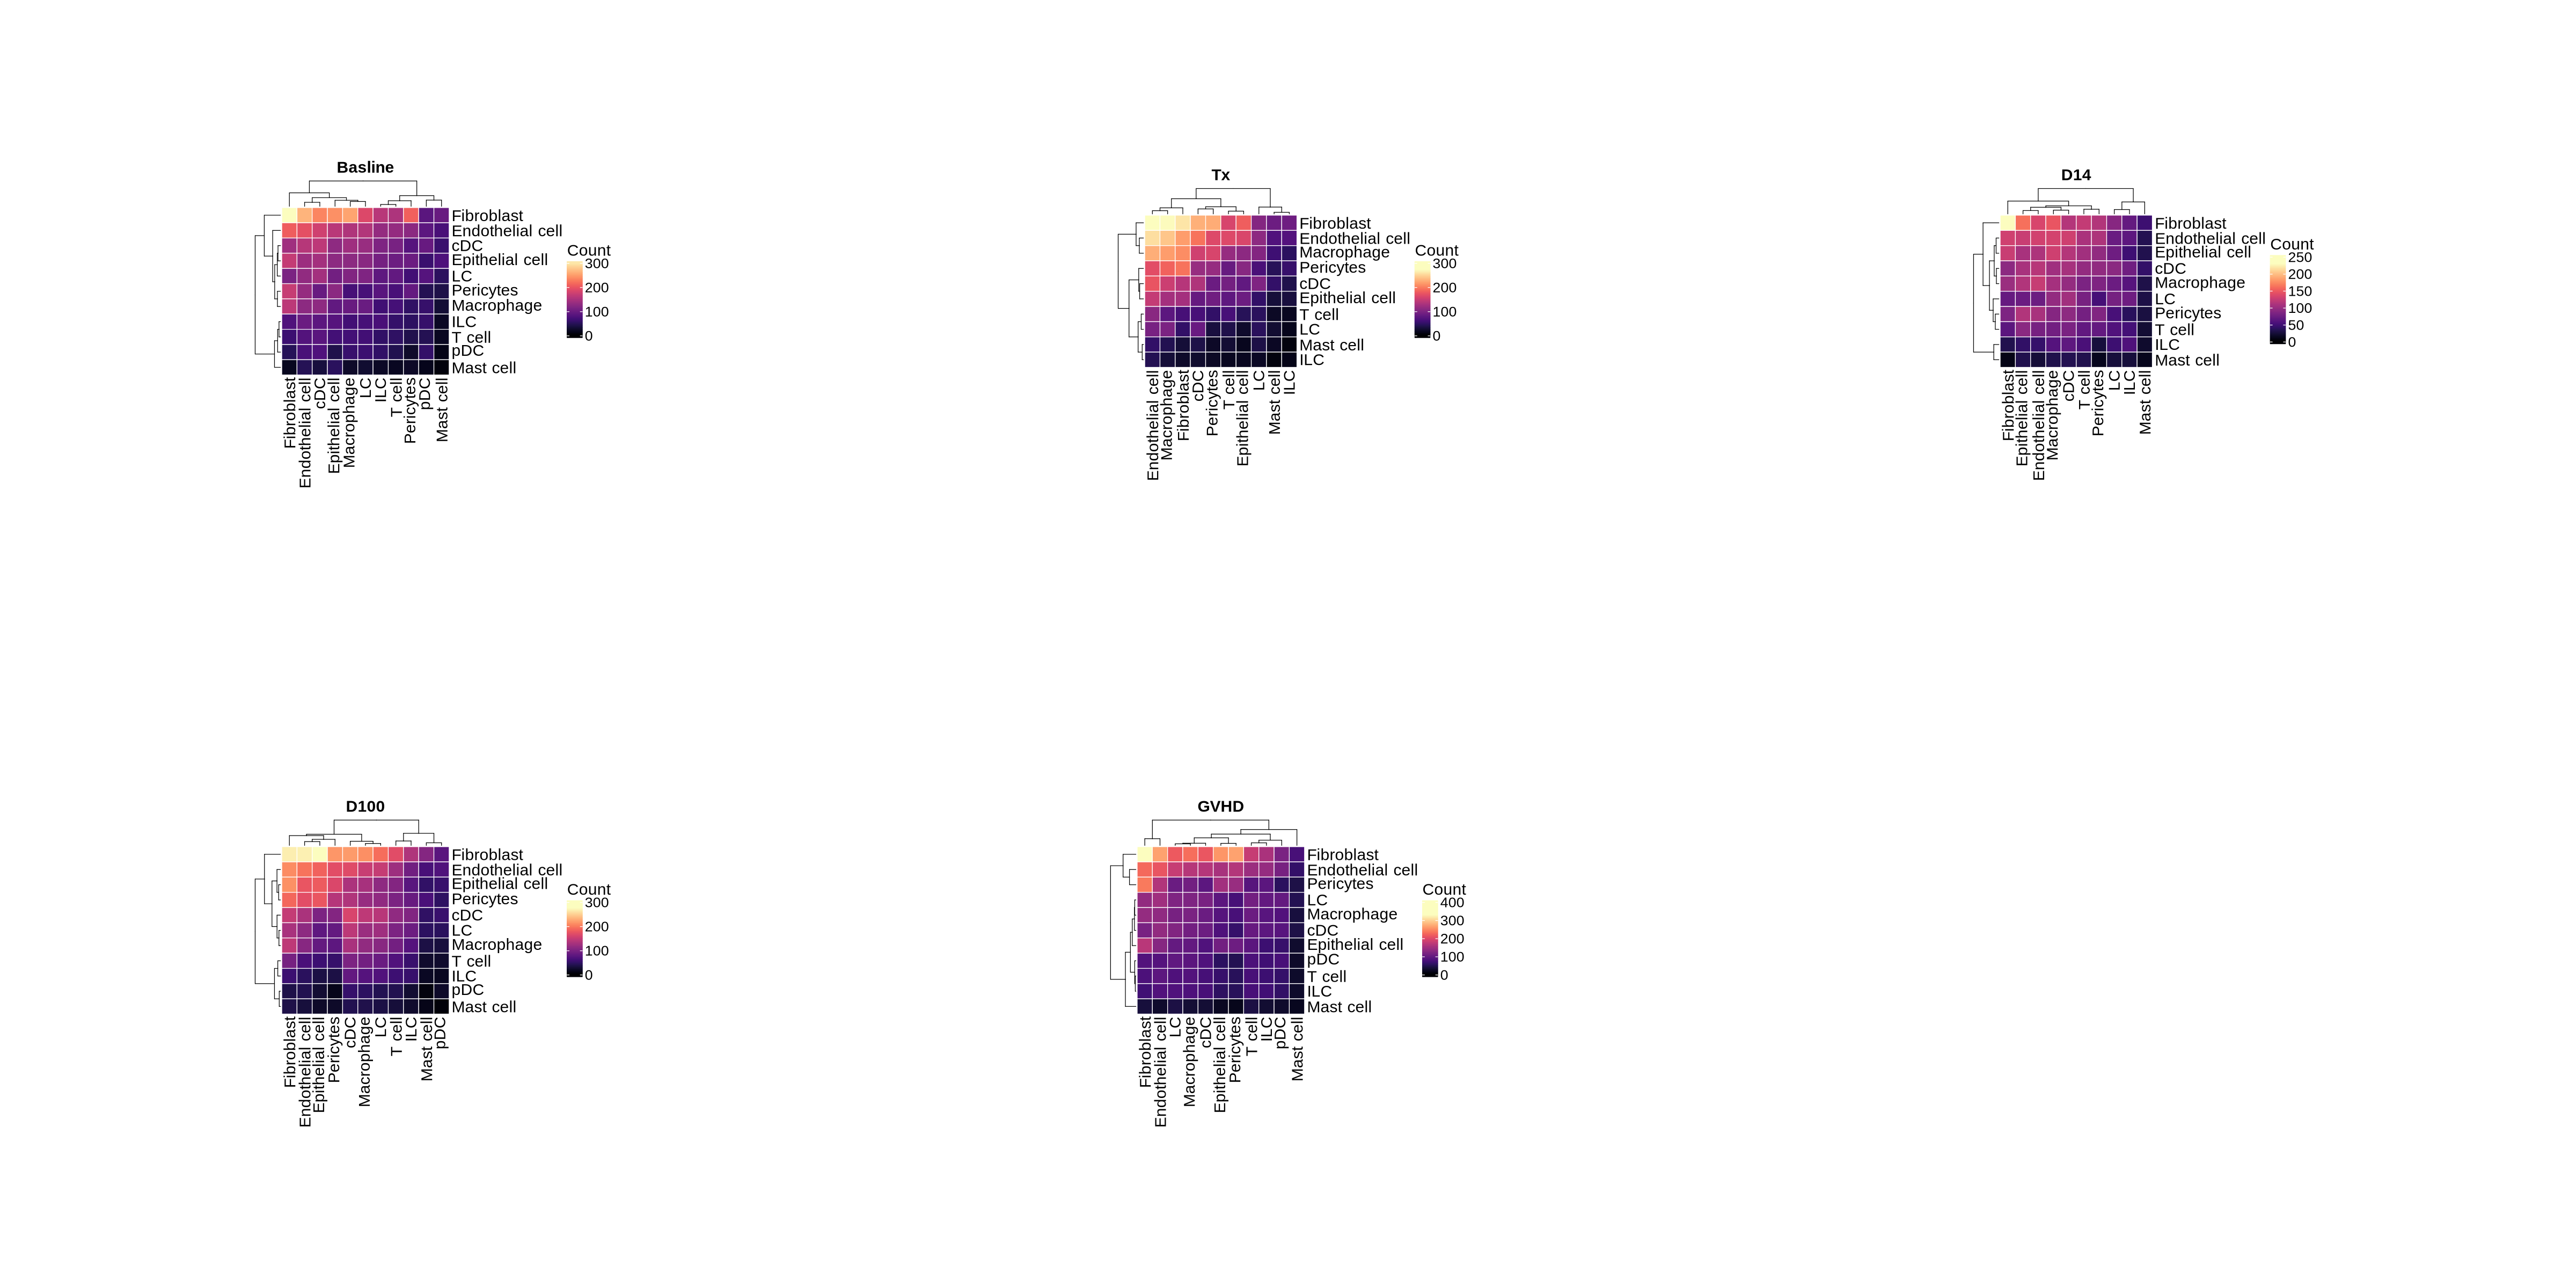

In [12]:
options(repr.plot.width=40, repr.plot.height=20)

patchwork::wrap_plots(list(hm_1, hm_2, hm_3, hm_4, hm_5), ncol=3)

# log2FC number of interactions 

In [13]:
celltype_diff_1 <- intersect(levels(cellchat_1@idents), levels(cellchat_2@idents))
object_list_1 <- list(Baseline=cellchat_1, Tx=cellchat_2)
cellchat_diff_1 <- mergeCellChat(object_list_1, add.names=names(object_list_1)) 
cellchat_diff_1 <- liftCellChat(cellchat_diff_1, group.new=union(rownames(cellchat_1@net[[1]]), rownames(cellchat_2@net[[1]])))

celltype_diff_2 <- intersect(levels(cellchat_1@idents), levels(cellchat_3@idents))
object_list_2 <- list(Baseline=cellchat_1, D14=cellchat_3)
cellchat_diff_2 <- mergeCellChat(object_list_2, add.names=names(object_list_2))
cellchat_diff_2 <- liftCellChat(cellchat_diff_2, group.new=union(rownames(cellchat_1@net[[1]]), rownames(cellchat_3@net[[1]])))

celltype_diff_3 <- intersect(levels(cellchat_1@idents), levels(cellchat_4@idents))
object_list_3 <- list(Baseline=cellchat_1, D100=cellchat_4)
cellchat_diff_3 <- mergeCellChat(object_list_3, add.names=names(object_list_3))
cellchat_diff_3 <- liftCellChat(cellchat_diff_3, group.new=union(rownames(cellchat_1@net[[1]]), rownames(cellchat_4@net[[1]])))

celltype_diff_4 <- intersect(levels(cellchat_1@idents), levels(cellchat_5@idents))
object_list_4 <- list(Baseline=cellchat_1, GVHD=cellchat_5)
cellchat_diff_4 <- mergeCellChat(object_list_4, add.names=names(object_list_4))
cellchat_diff_4 <- liftCellChat(cellchat_diff_4, group.new=union(rownames(cellchat_1@net[[1]]), rownames(cellchat_5@net[[1]])))

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.

The CellChat object will be lifted up using the cell labels Fibroblast, Epithelial~cell, Endothelial~cell, Pericytes, T~cell, ILC, Macrophage, cDC, LC, pDC, Mast~cell



Update slots object@net, object@netP, object@idents in dataset  Baseline 
Update slots object@net, object@netP, object@idents in dataset  Tx 


Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.

The CellChat object will be lifted up using the cell labels Fibroblast, Epithelial~cell, Endothelial~cell, Pericytes, T~cell, ILC, Macrophage, cDC, LC, pDC, Mast~cell



Update slots object@net, object@netP, object@idents in dataset  Baseline 
Update slots object@net, object@netP, object@idents in dataset  D14 


Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.

The CellChat object will be lifted up using the cell labels Fibroblast, Epithelial~cell, Endothelial~cell, Pericytes, T~cell, ILC, Macrophage, cDC, LC, pDC, Mast~cell



Update slots object@net, object@netP, object@idents in dataset  Baseline 
Update slots object@net, object@netP, object@idents in dataset  D100 


Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.

The CellChat object will be lifted up using the cell labels Fibroblast, Epithelial~cell, Endothelial~cell, Pericytes, T~cell, ILC, Macrophage, cDC, LC, pDC, Mast~cell



Update slots object@net, object@netP, object@idents in dataset  Baseline 
Update slots object@net, object@netP, object@idents in dataset  GVHD 


In [14]:
# options(repr.plot.width=10, repr.plot.height=10)

# hm_1 <- hm_net(cellchat_diff_1, slot="count", title="Skin Baseline vs Tx", diff=TRUE) %>% draw() %>% grid.grabExpr()
# hm_2 <- hm_net(cellchat_diff_2, slot="count", title="Skin Baseline vs D14", diff=TRUE) %>% draw() %>% grid.grabExpr()
# hm_3 <- hm_net(cellchat_diff_3, slot="count", title="Skin Baseline vs D100", diff=TRUE) %>% draw() %>% grid.grabExpr()
# hm_4 <- hm_net(cellchat_diff_4, slot="count", title="Skin Baseline vs GVHD", diff=TRUE) %>% draw() %>% grid.grabExpr()

In [15]:
# options(repr.plot.width=40, repr.plot.height=10)

# patchwork::wrap_plots(list(hm_1, hm_2, hm_3, hm_4), ncol=4)

In [16]:
options(repr.plot.width=10, repr.plot.height=10)

hm_1 <- hm_net(cellchat_diff_1, slot="count", title="Skin Baseline vs Tx", diff=TRUE, celltype=celltype_diff_1) %>% draw() %>% grid.grabExpr()
hm_2 <- hm_net(cellchat_diff_2, slot="count", title="Skin Baseline vs D14", diff=TRUE, celltype=celltype_diff_2) %>% draw() %>% grid.grabExpr()
hm_3 <- hm_net(cellchat_diff_3, slot="count", title="Skin Baseline vs D100", diff=TRUE, celltype=celltype_diff_3) %>% draw() %>% grid.grabExpr()
hm_4 <- hm_net(cellchat_diff_4, slot="count", title="Skin Baseline vs GVHD", diff=TRUE, celltype=celltype_diff_4) %>% draw() %>% grid.grabExpr()

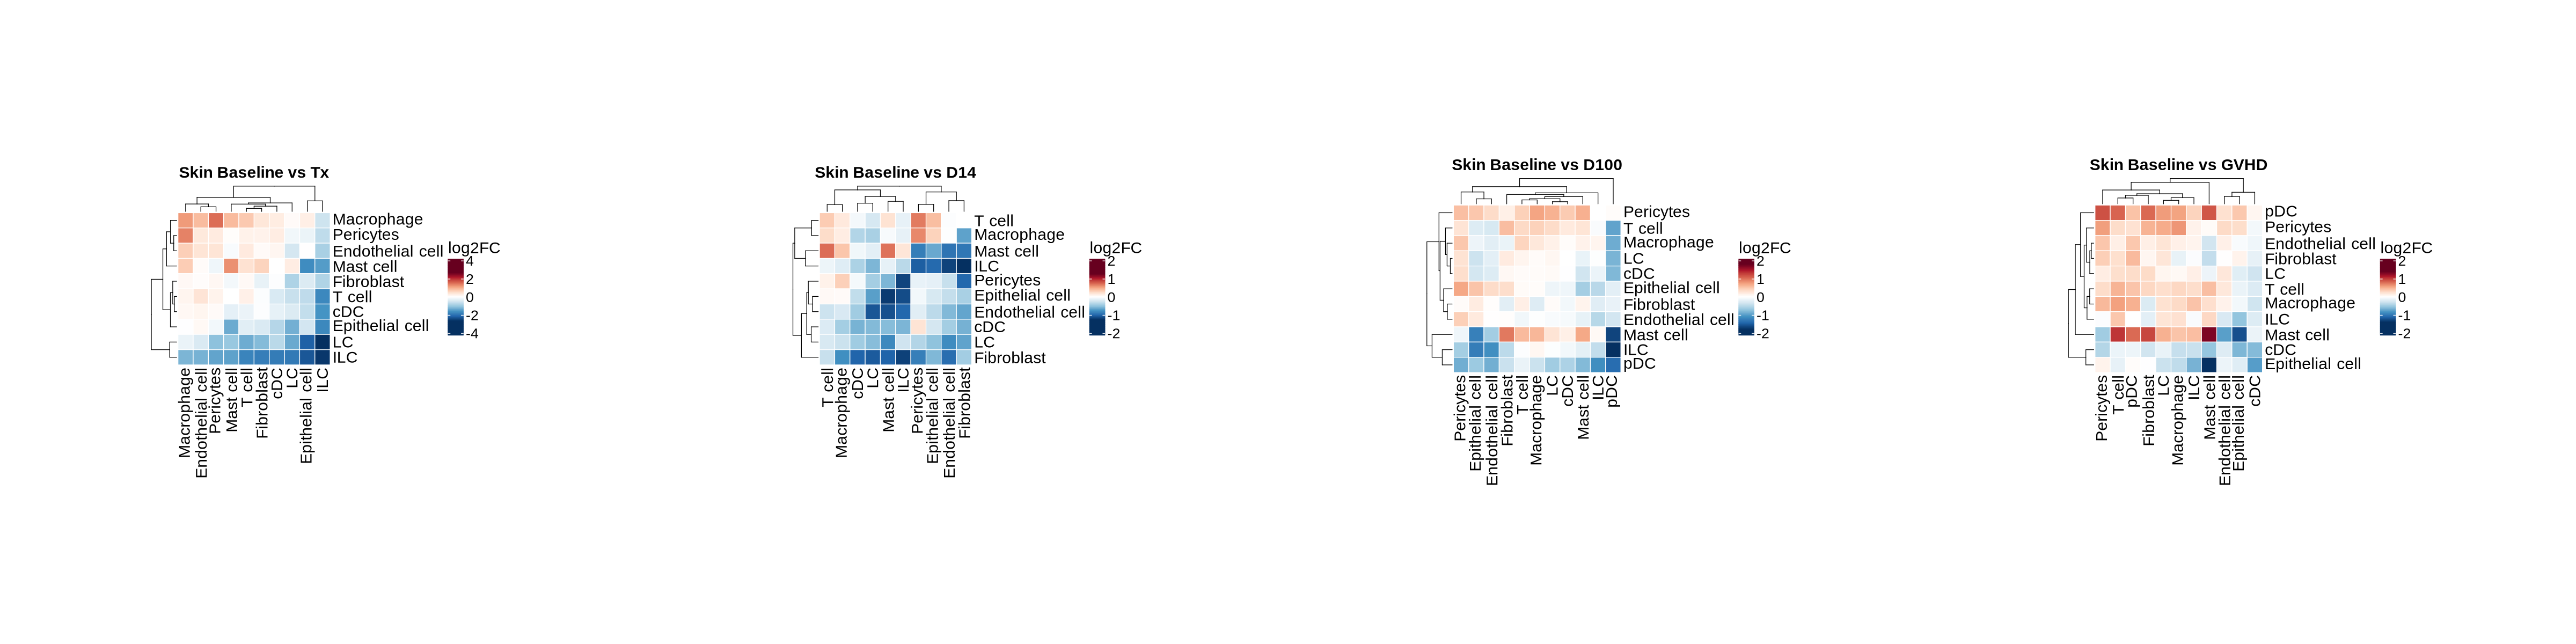

In [17]:
options(repr.plot.width=40, repr.plot.height=10)

patchwork::wrap_plots(list(hm_1, hm_2, hm_3, hm_4), ncol=4)

# Net analysis all cell types between groups

In [18]:
plot_1 <- rankNet(cellchat_diff_1, mode="comparison", stacked=TRUE, do.stat=TRUE) + theme_global_set(1) + ggtitle("Tx") + scale_fill_manual(values=color$time_point)
plot_2 <- rankNet(cellchat_diff_2, mode="comparison", stacked=TRUE, do.stat=TRUE) + theme_global_set(1) + ggtitle("D14") + scale_fill_manual(values=color$time_point)
plot_3 <- rankNet(cellchat_diff_3, mode="comparison", stacked=TRUE, do.stat=TRUE) + theme_global_set(1) + ggtitle("D100") + scale_fill_manual(values=color$time_point)
plot_4 <- rankNet(cellchat_diff_4, mode="comparison", stacked=TRUE, do.stat=TRUE) + theme_global_set(1) + ggtitle("GVHD") + scale_fill_manual(values=color$time_point)

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


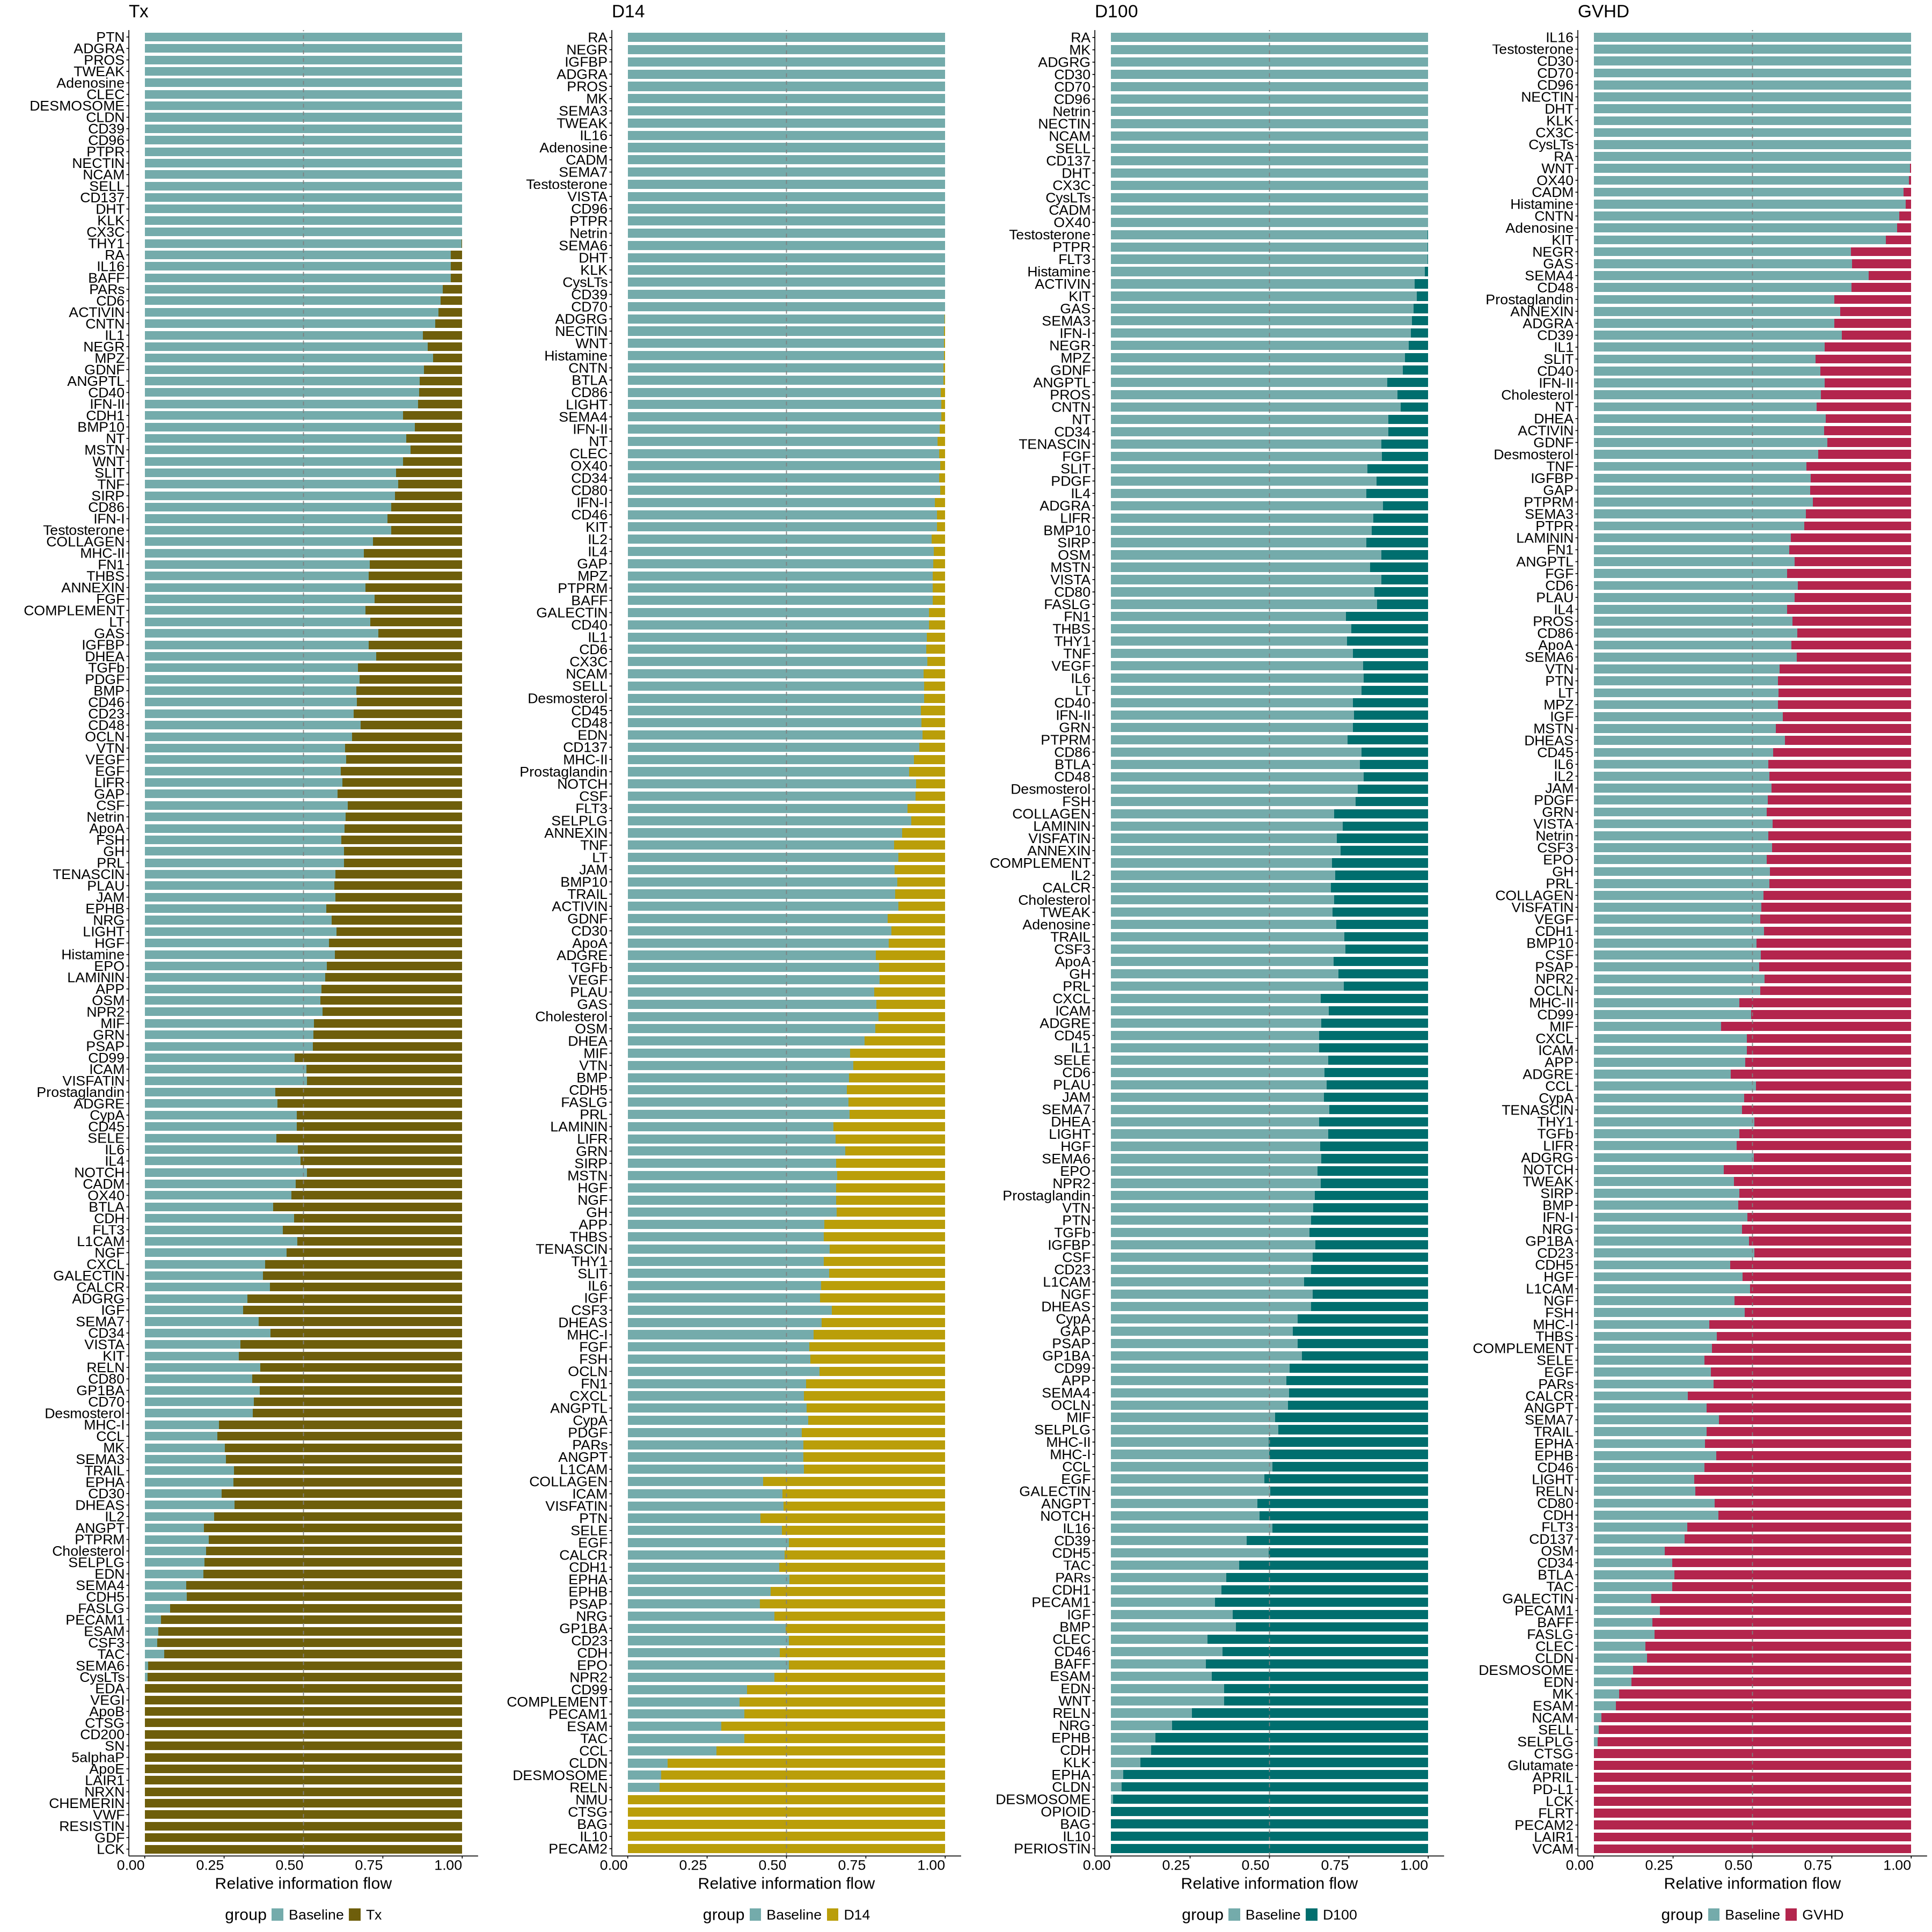

In [19]:
options(repr.plot.width=5*6, repr.plot.height=30)

ggpubr::ggarrange(plotlist=list(plot_1, plot_2, plot_3, plot_4), ncol=4, nrow=1, common.legend=FALSE, legend="bottom")

# Signaling strength

Signaling role analysis on the aggregated cell-cell communication network from all signaling pathways

Signaling role analysis on the aggregated cell-cell communication network from all signaling pathways

Signaling role analysis on the aggregated cell-cell communication network from all signaling pathways

Signaling role analysis on the aggregated cell-cell communication network from all signaling pathways

Signaling role analysis on the aggregated cell-cell communication network from all signaling pathways



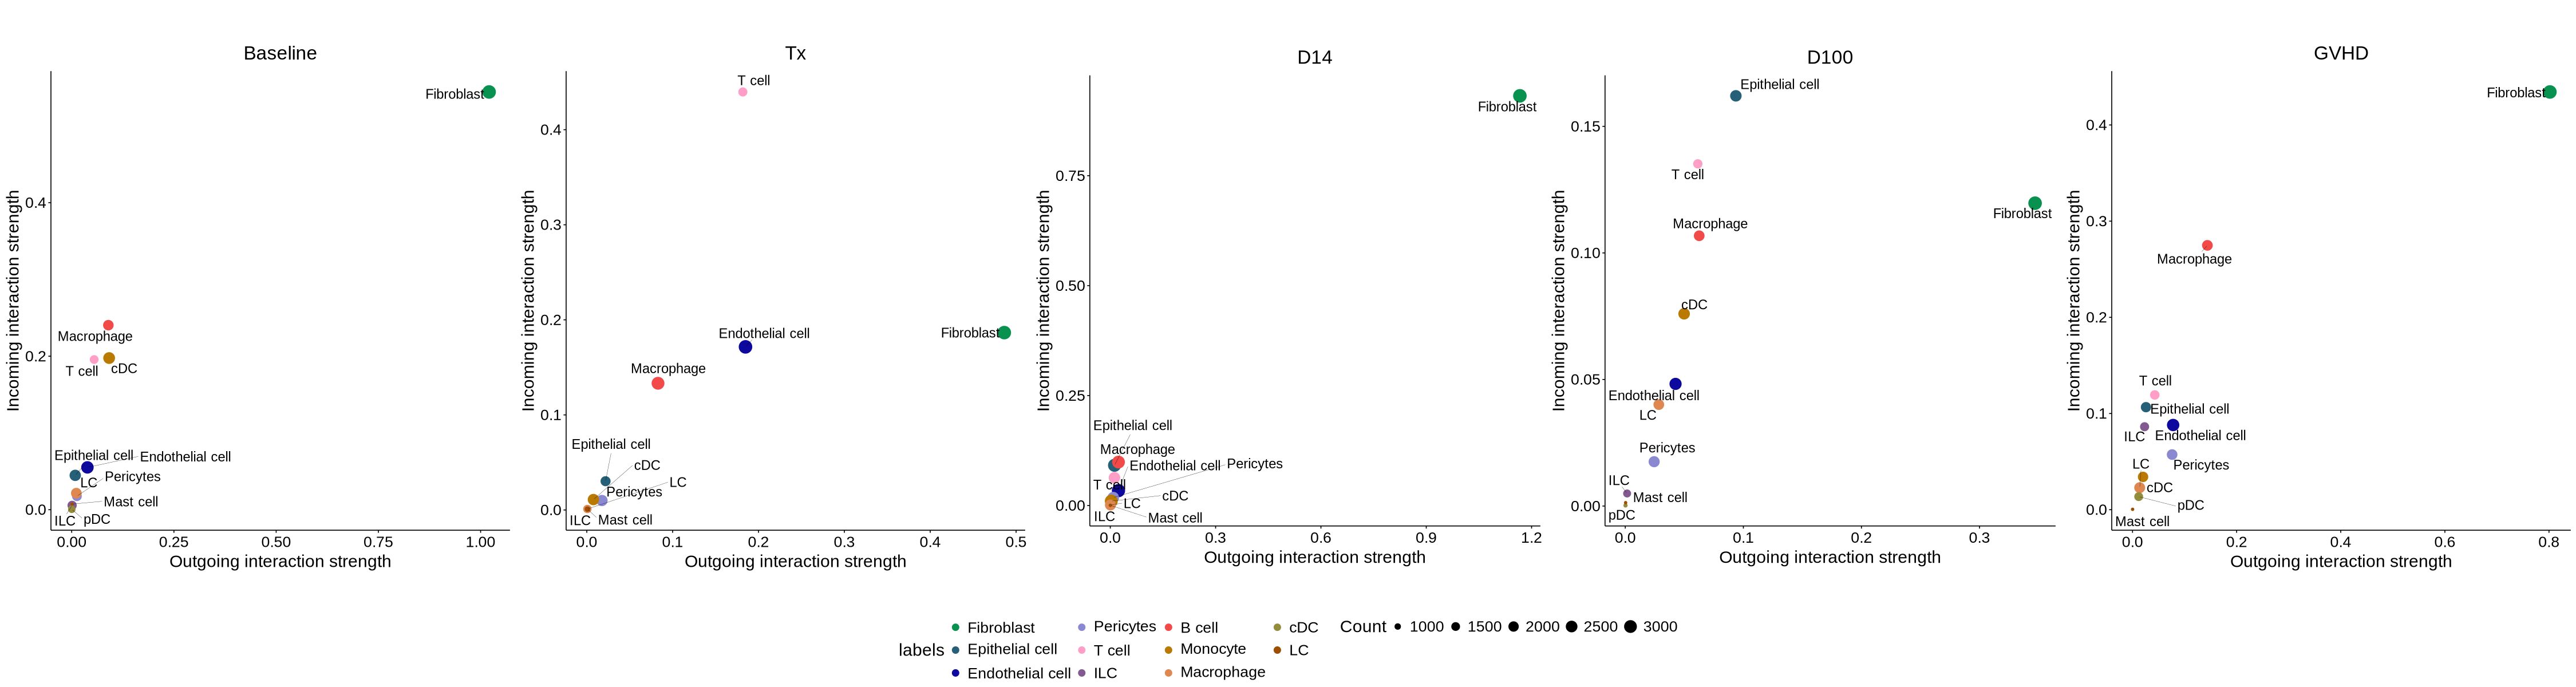

In [20]:
options(repr.plot.width=5*7.5, repr.plot.height=10)

object_list <- list(cellchat_1, cellchat_2, cellchat_3, cellchat_4, cellchat_5)
names(object_list) <- c("Baseline", "Tx", "D14", "D100", "GVHD")

num_link <- sapply(object_list, function(x) {rowSums(x@net$count) + colSums(x@net$count)-diag(x@net$count)})
weight_lim <- c(min(unlist(num_link)), max(unlist(num_link))) # control the dot size in the different datasets

net_plot_list <- list()
for (i in names(object_list)) {
    
    data <- netAnalysis_signalingRole_scatter(object_list[[i]], title=names(object_list)[i], weight.MinMax=weight_lim)$data
    
    net_plot <- ggplot(data, aes(x=x, y=y, label=labels, size=Count, color=labels)) + 
        geom_point() + 
        geom_text_repel(segment.color="black", force=20, force_pull=1, max.overlaps=getOption("ggrepel.max.overlaps", default=100), size=5, alpha=1, guide="none", segment.size=0.1, color="black", parse=TRUE) + 
        scale_color_manual(values=color$celltype_high_r, na.value="grey50", labels=base::str2expression(names(color$celltype_high_r))) + 
        guides(colour=guide_legend(override.aes=list(size=3))) + 
        ggtitle(i) + xlab("Outgoing interaction strength") + ylab("Incoming interaction strength") + 
        theme_global_set(1) + theme(aspect.ratio=1)
    
    
    net_plot_list[[i]] <- net_plot

}

ggpubr::ggarrange(plotlist=net_plot_list, ncol=5, nrow=1, common.legend=TRUE, legend="bottom")

# Net analysis outgoing/incoming signals per cell type between groups

In [21]:
suppressMessages(plot_1 <- lapply(levels(cellchat_diff_1@idents[[3]]), function(ident) {netAnalysis_signalingChanges_scatter(cellchat_diff_1, idents.use=ident, label.size=4, dot.size=5, color.use=c("#9C9C9C", color$time_point[[1]], color$time_point[[2]])) + ggtitle(parse(text=ident)) + theme_global_set(size=2)}))
suppressMessages(plot_2 <- lapply(levels(cellchat_diff_2@idents[[3]]), function(ident) {netAnalysis_signalingChanges_scatter(cellchat_diff_2, idents.use=ident, label.size=4, dot.size=5, color.use=c("#9C9C9C", color$time_point[[1]], color$time_point[[3]])) + ggtitle(parse(text=ident)) + theme_global_set(size=2)}))
suppressMessages(plot_3 <- lapply(levels(cellchat_diff_3@idents[[3]]), function(ident) {netAnalysis_signalingChanges_scatter(cellchat_diff_3, idents.use=ident, label.size=4, dot.size=5, color.use=c("#9C9C9C", color$time_point[[1]], color$time_point[[4]])) + ggtitle(parse(text=ident)) + theme_global_set(size=2)}))
suppressMessages(plot_4 <- lapply(levels(cellchat_diff_4@idents[[3]]), function(ident) {netAnalysis_signalingChanges_scatter(cellchat_diff_4, idents.use=ident, label.size=4, dot.size=5, color.use=c("#9C9C9C", color$time_point[[1]], color$time_point[[5]])) + ggtitle(parse(text=ident)) + theme_global_set(size=2)}))

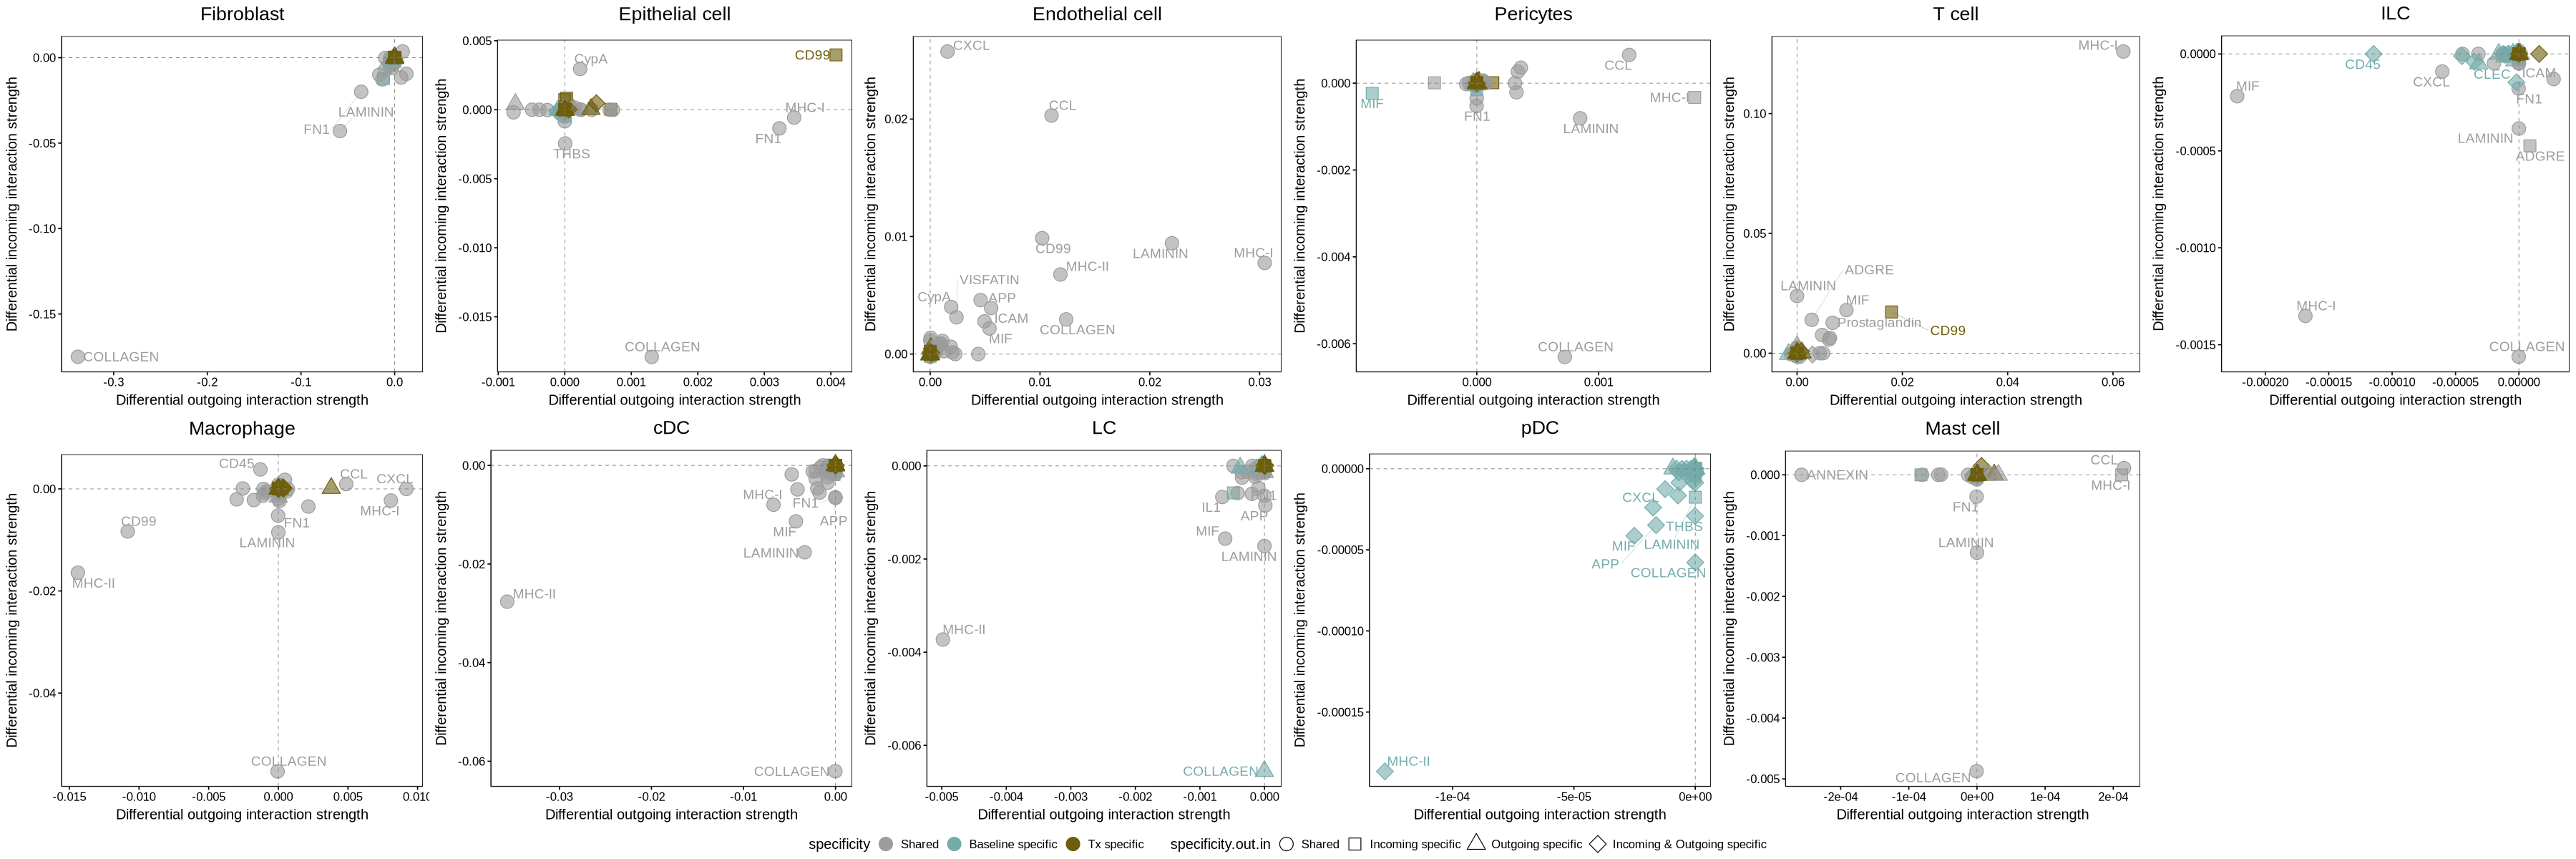

In [22]:
options(repr.plot.width=6*5, repr.plot.height=ceiling(length(plot_1)/6)*5)

ggpubr::ggarrange(plotlist=plot_1, ncol=6, nrow=ceiling(length(plot_1)/6), common.legend=TRUE, legend="bottom")

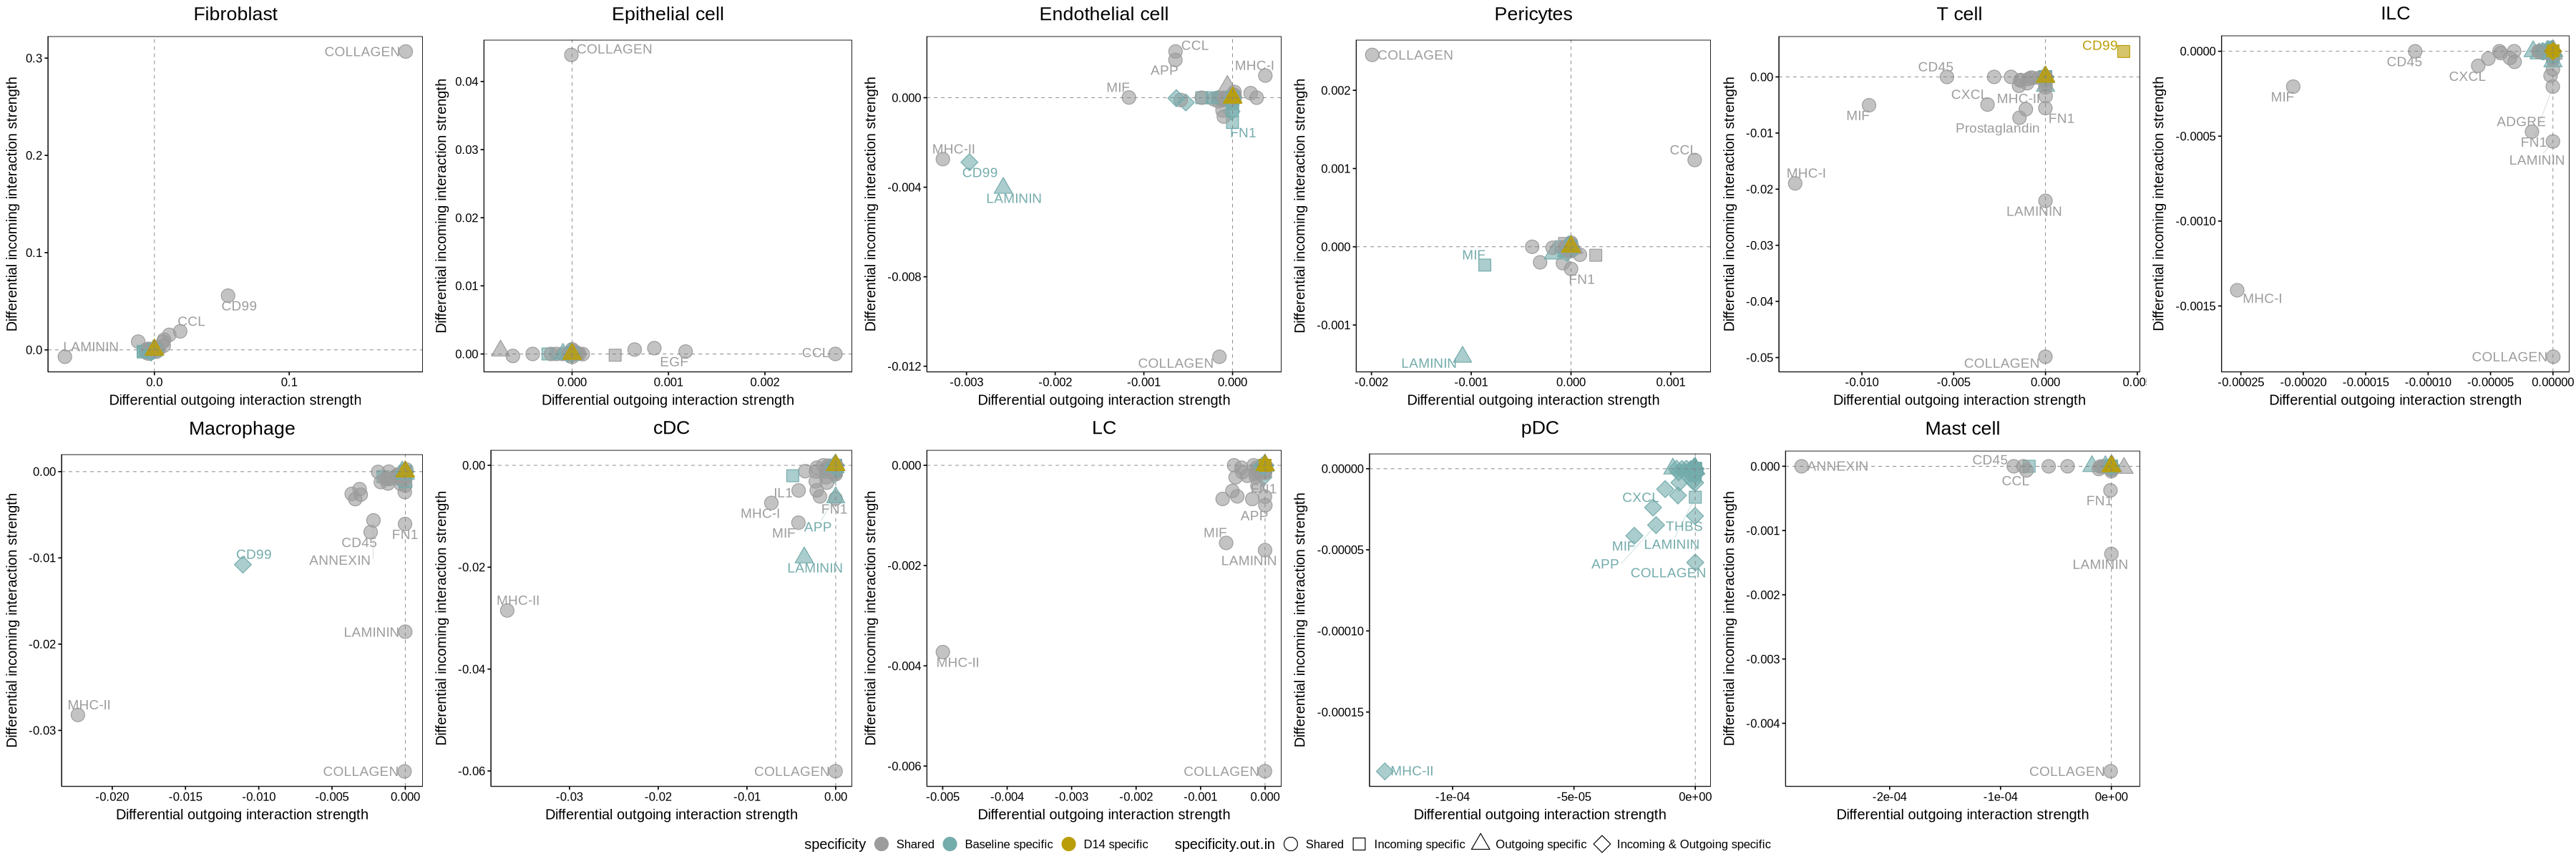

In [23]:
options(repr.plot.width=6*5, repr.plot.height=ceiling(length(plot_2)/6)*5)

ggpubr::ggarrange(plotlist=plot_2, ncol=6, nrow=ceiling(length(plot_2)/6), common.legend=TRUE, legend="bottom")

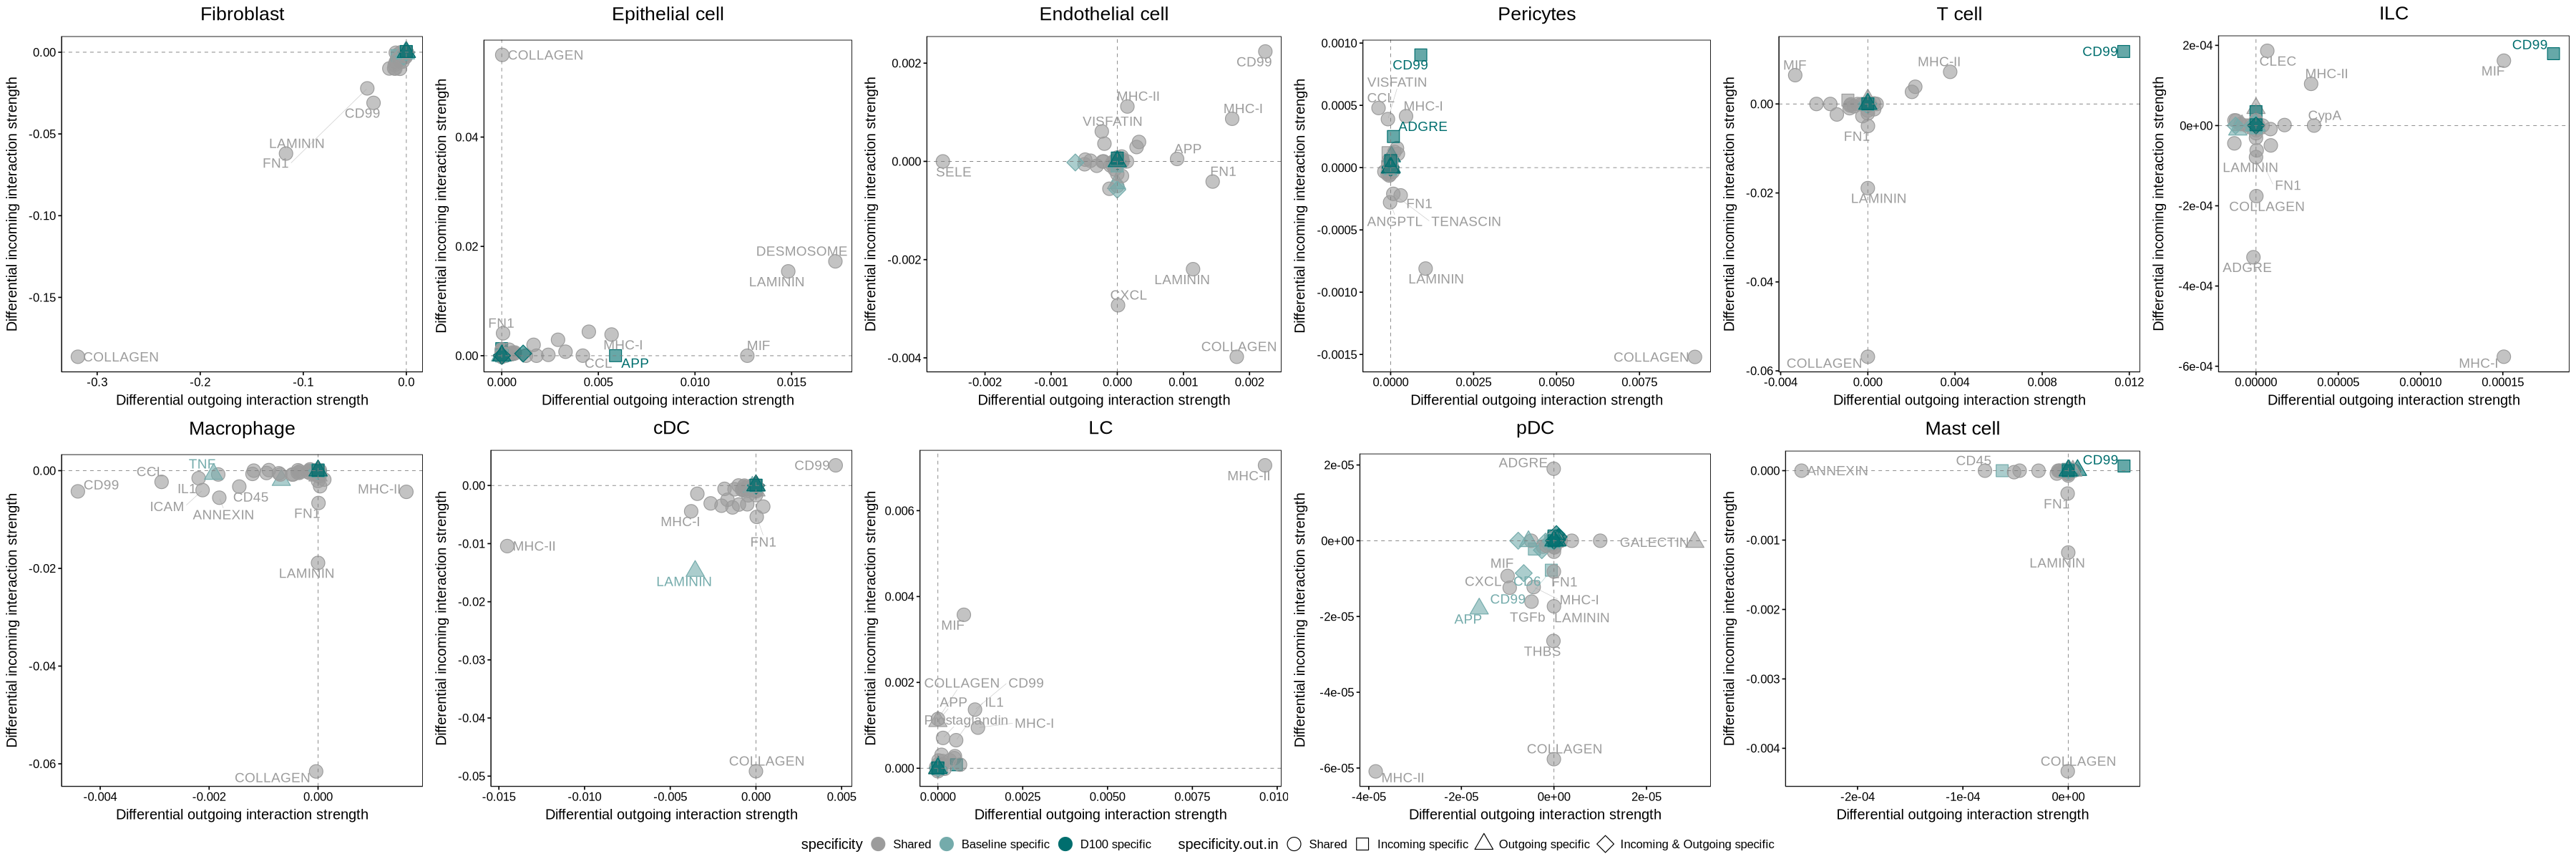

In [24]:
options(repr.plot.width=6*5, repr.plot.height=ceiling(length(plot_3)/6)*5)

ggpubr::ggarrange(plotlist=plot_3, ncol=6, nrow=ceiling(length(plot_3)/6), common.legend=TRUE, legend="bottom")

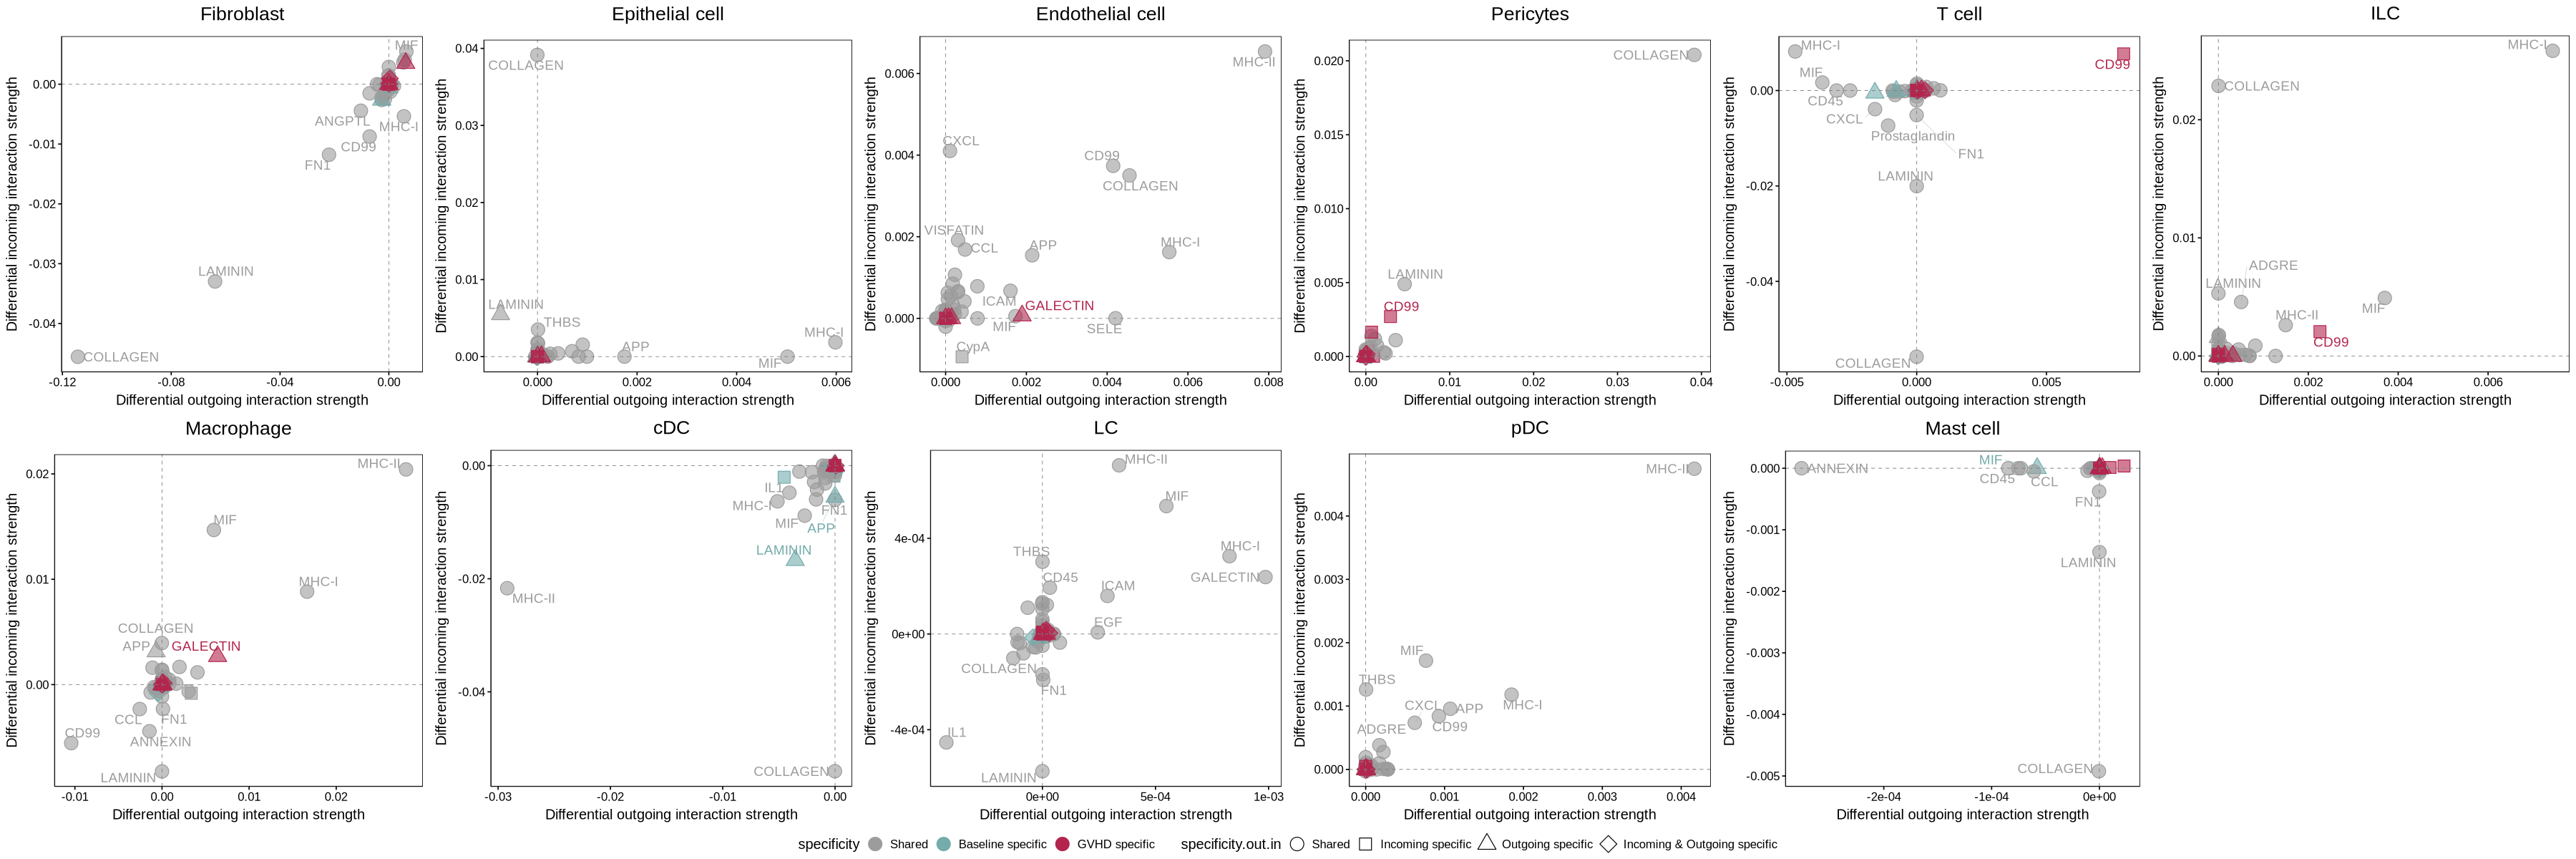

In [25]:
options(repr.plot.width=6*5, repr.plot.height=ceiling(length(plot_4)/6)*5)

ggpubr::ggarrange(plotlist=plot_4, ncol=6, nrow=ceiling(length(plot_4)/6), common.legend=TRUE, legend="bottom")

# Net analysis all cell types between groups

In [26]:
plot_1 <- rankNet(cellchat_diff_1, mode="comparison", stacked=TRUE, do.stat=TRUE) + theme_global_set(1) + ggtitle("Tx") + scale_fill_manual(values=color$time_point)
plot_2 <- rankNet(cellchat_diff_2, mode="comparison", stacked=TRUE, do.stat=TRUE) + theme_global_set(1) + ggtitle("D14") + scale_fill_manual(values=color$time_point)
plot_3 <- rankNet(cellchat_diff_3, mode="comparison", stacked=TRUE, do.stat=TRUE) + theme_global_set(1) + ggtitle("D100") + scale_fill_manual(values=color$time_point)
plot_4 <- rankNet(cellchat_diff_4, mode="comparison", stacked=TRUE, do.stat=TRUE) + theme_global_set(1) + ggtitle("GVHD") + scale_fill_manual(values=color$time_point)

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


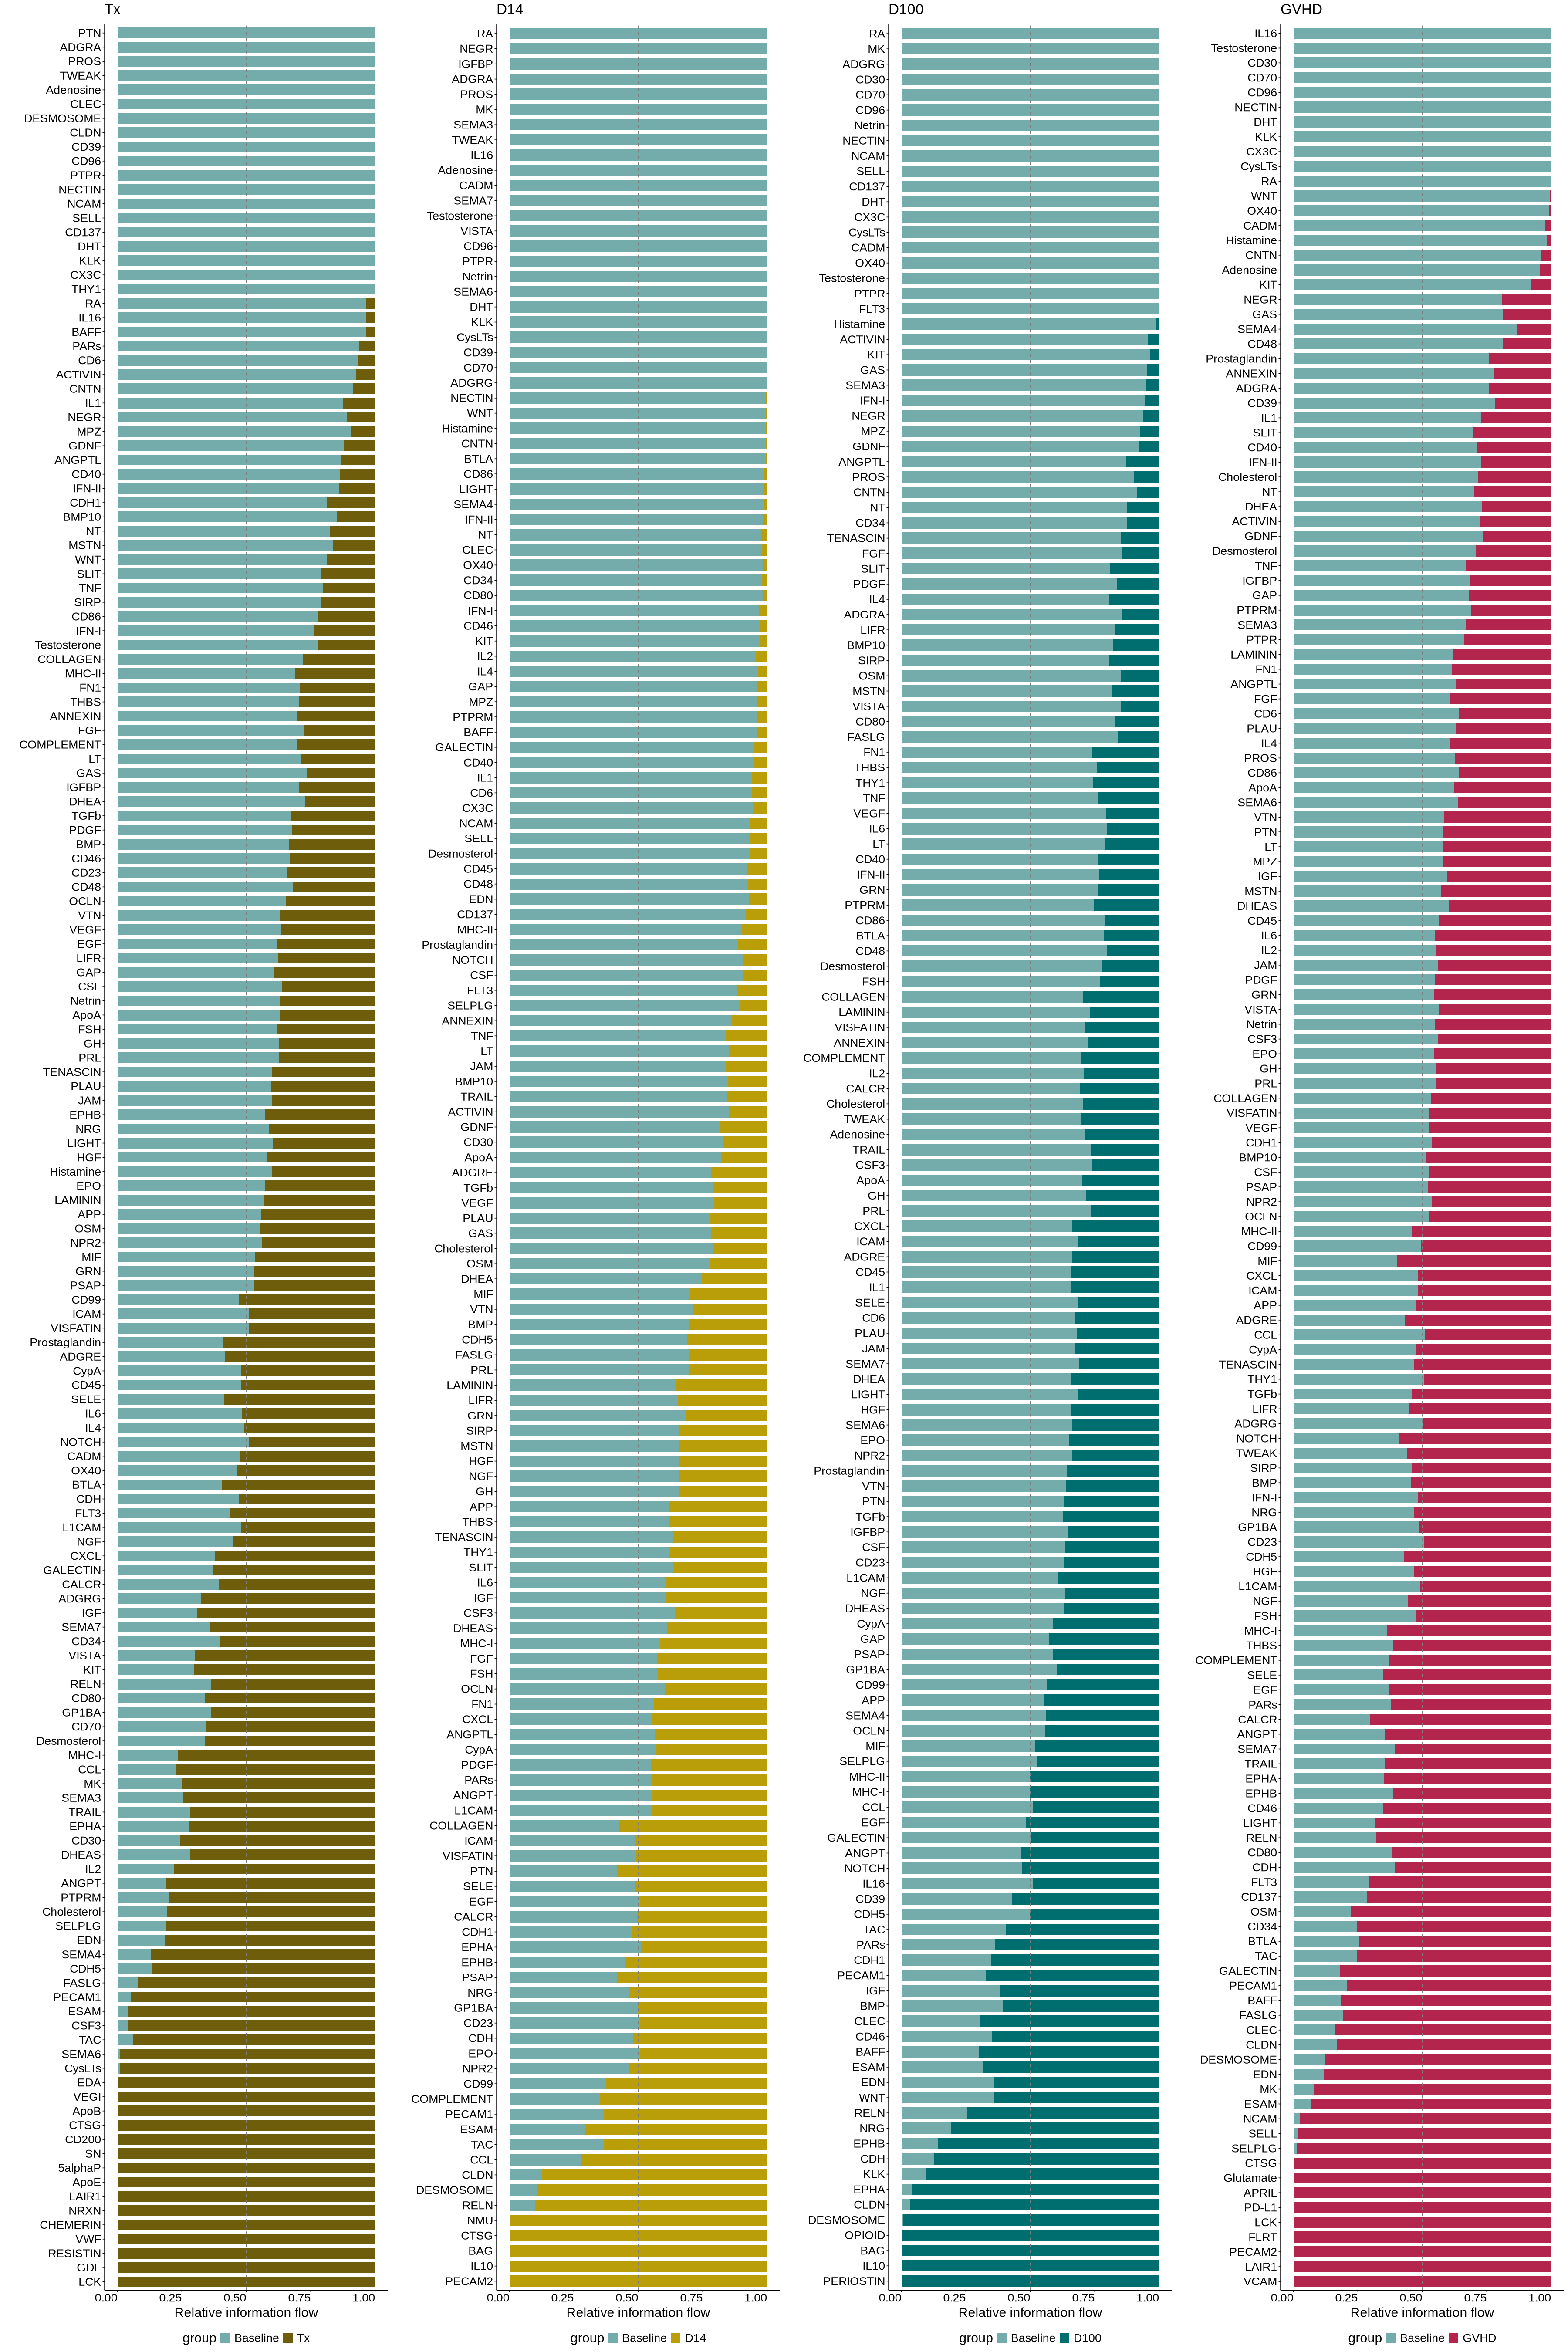

In [27]:
options(repr.plot.width=5*6, repr.plot.height=45)

ggpubr::ggarrange(plotlist=list(plot_1, plot_2, plot_3, plot_4), ncol=4, nrow=1, common.legend=FALSE, legend="bottom")

# Net analysisof significant interactions within time points

In [ ]:
# options(repr.plot.width=4*10, repr.plot.height=40)

# plot_1 <- suppressMessages(lapply(seq_along(levels(cellchat_1@idents)), function(i) {netVisual_bubble(cellchat_1, sources.use=i, remove.isolate=FALSE, thresh=0.01, title.name=parse(text=levels(cellchat_1@idents)[i]))}))
# ggpubr::ggarrange(plotlist=plot_1, ncol=4, nrow=1, common.legend=FALSE, legend="bottom")

In [ ]:
# options(repr.plot.width=4*10, repr.plot.height=40)

# plot_2 <- suppressMessages(lapply(seq_along(levels(cellchat_2@idents)), function(i) {netVisual_bubble(cellchat_2, sources.use=i, remove.isolate=FALSE, thresh=0.01, title.name=parse(text=levels(cellchat_2@idents)[i]))}))
# ggpubr::ggarrange(plotlist=plot_2, ncol=4, nrow=1, common.legend=FALSE, legend="bottom")

In [ ]:
# options(repr.plot.width=4*10, repr.plot.height=40)

# plot_3 <- suppressMessages(lapply(seq_along(levels(cellchat_3@idents)), function(i) {netVisual_bubble(cellchat_3, sources.use=i, remove.isolate=FALSE, thresh=0.01, title.name=parse(text=levels(cellchat_3@idents)[i]))}))
# ggpubr::ggarrange(plotlist=plot_3, ncol=4, nrow=1, common.legend=FALSE, legend="bottom")

In [ ]:
# options(repr.plot.width=4*10, repr.plot.height=40)

# plot_4 <- suppressMessages(lapply(seq_along(levels(cellchat_4@idents)), function(i) {netVisual_bubble(cellchat_4, sources.use=i, remove.isolate=FALSE, thresh=0.01, title.name=parse(text=levels(cellchat_4@idents)[i]))}))
# ggpubr::ggarrange(plotlist=plot_4, ncol=4, nrow=1, common.legend=FALSE, legend="bottom")

In [ ]:
# options(repr.plot.width=4*10, repr.plot.height=40)

# plot_5 <- suppressMessages(lapply(seq_along(levels(cellchat_5@idents)), function(i) {netVisual_bubble(cellchat_5, sources.use=i, remove.isolate=FALSE, thresh=0.01, title.name=parse(text=levels(cellchat_5@idents)[i]))}))
# ggpubr::ggarrange(plotlist=plot_5, ncol=4, nrow=1, common.legend=FALSE, legend="bottom")

# Net analysis of significant interactions enriched in baseline compared to GVHD

In [ ]:
# options(repr.plot.width=4*10, repr.plot.height=40)

# plot_1 <- suppressMessages(lapply(celltype_diff_1, function(i) {
    
#     tryCatch(
        
#         {
#             netVisual_bubble(cellchat_diff_1, sources.use=i, comparison=c(1, 2), remove.isolate=TRUE, thresh=0.01, title.name=parse(text=i), color.text=color$time_point[c(1, 2)], font.size.title=20, fon=16, max.dataset=1)
        
#         }, error=function(e) {
            
#             NULL
        
#         }
    
#     )

# }
#                                  )
                          
#                           )

# ggpubr::ggarrange(plotlist=plot_1[!sapply(plot_1, is.null)], ncol=4, nrow=1, common.legend=FALSE, legend="bottom")

In [ ]:
# options(repr.plot.width=4*10, repr.plot.height=40)

# plot_2 <- suppressMessages(lapply(seq_along(levels(cellchat_diff_2@idents$joint)), function(i) {
    
#     tryCatch(
        
#         {
#             netVisual_bubble(cellchat_diff_2, sources.use=i, comparison=c(1, 2), remove.isolate=FALSE, thresh=0.01, title.name=parse(text=levels(cellchat_diff_2@idents$joint)[i]), color.text=color$time_point[c(1, 3)], max.dataset=1)
        
#         }, error=function(e) {
            
#             patchwork::plot_spacer
        
#         }
    
#     )

# }
#                                  )
                          
#                           )

# ggpubr::ggarrange(plotlist=plot_2[!sapply(plot_2, is.null)], ncol=4, nrow=1, common.legend=FALSE, legend="bottom")

In [ ]:
# options(repr.plot.width=4*10, repr.plot.height=40)

# plot_3 <- suppressMessages(lapply(seq_along(levels(cellchat_diff_3@idents$joint)), function(i) {
    
#     tryCatch(
        
#         {
#             netVisual_bubble(cellchat_diff_3, sources.use=i, comparison=c(1, 2), remove.isolate=FALSE, thresh=0.01, title.name=parse(text=levels(cellchat_diff_3@idents$joint)[i]), color.text=color$time_point[c(1, 4)], max.dataset=1)
        
#         }, error=function(e) {
            
#             patchwork::plot_spacer
        
#         }
    
#     )

# }
#                                  )
                          
#                           )

# ggpubr::ggarrange(plotlist=plot_3[!sapply(plot_3, is.null)], ncol=4, nrow=1, common.legend=FALSE, legend="bottom")

In [ ]:
# options(repr.plot.width=4*10, repr.plot.height=40)

# plot_4 <- suppressMessages(lapply(levels(cellchat_diff_4@idents$joint), function(i) {
    
#     tryCatch(
        
#         {
#             netVisual_bubble(cellchat_diff_4, sources.use=i, comparison=c(1, 2), remove.isolate=FALSE, thresh=0.01, title.name=parse(text=i), color.text=color$time_point[c(1, 5)], max.dataset=1, font.size.title=20, fon=16)
        
#         }, error=function(e) {
            
#             patchwork::plot_spacer
        
#         }
    
#     )

# }
#                                  )
                          
#                           )

# ggpubr::ggarrange(plotlist=plot_4[!sapply(plot_4, is.null)], ncol=4, nrow=1, common.legend=FALSE, legend="bottom")

# Session info

In [ ]:
sessionInfo()